In [75]:
!pip install tensorflow

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import seaborn as sns
import pandas as pd

In [76]:
model = models.Sequential()
model.add(layers.Input(shape=(28, 28, 1)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

In [77]:
#print (tf.__version__)
%reload_ext tensorboard
logdir='log'
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()
train_images, train_images.reshape(60000, 28, 28, 1)
test_images = test_images.reshape(10000, 28, 28, 1)
train_images, test_images = train_images / 255.0, test_images / 255.0
classes=[0,1,2,3,4,5,6,7,8,9]

In [78]:
model = models.Sequential()
model.add(layers.Input(shape=(28, 28, 1)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

In [79]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [80]:
model.fit(train_images, train_labels, epochs=4,
          validation_data=(test_images, test_labels),
          callbacks=[tensorboard_callback])

Epoch 1/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9568 - loss: 0.1361 - val_accuracy: 0.9856 - val_loss: 0.0426
Epoch 2/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 35ms/step - accuracy: 0.9860 - loss: 0.0444 - val_accuracy: 0.9867 - val_loss: 0.0422
Epoch 3/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9895 - loss: 0.0322 - val_accuracy: 0.9912 - val_loss: 0.0281
Epoch 4/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 34ms/step - accuracy: 0.9922 - loss: 0.0235 - val_accuracy: 0.9916 - val_loss: 0.0275


### Avaliar a acurácia final do modelo

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


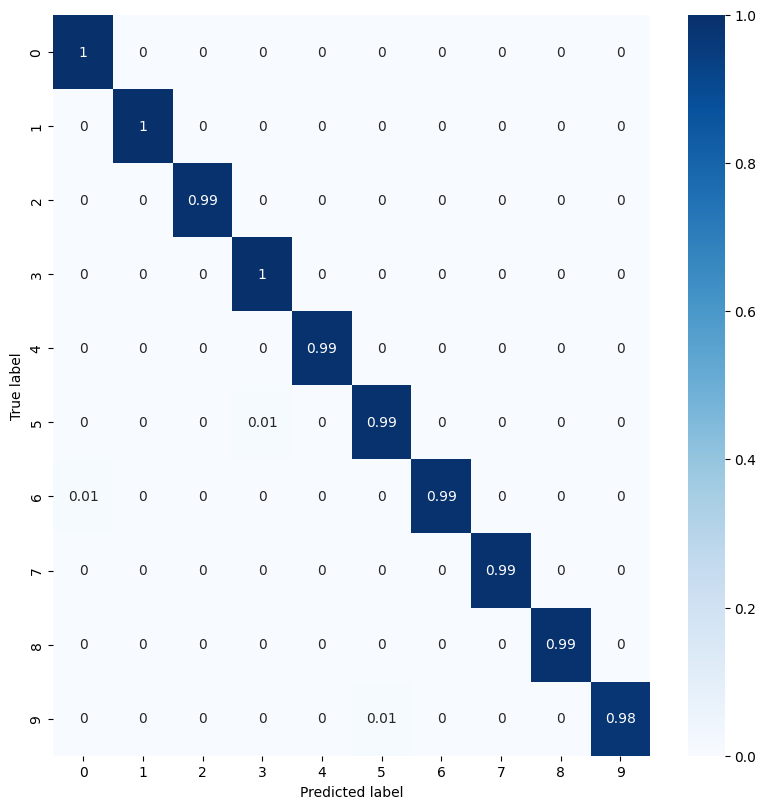

In [82]:
y_true=test_labels
y_pred=np.argmax(model.predict(test_images), axis=-1)

#classes=[0,1,2,3,4,5,6,7,8,9]

con_mat = tf.math.confusion_matrix(labels=y_true,predictions=y_pred).numpy()
con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=2)

con_mat_df = pd.DataFrame(con_mat_norm,
                         index = classes,
                         columns = classes)

figure = plt.figure(figsize=(8, 8))
sns.heatmap(con_mat_df, annot=True,cmap=plt.cm.Blues)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()
#

In [83]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'Acurácia no conjunto de teste: {test_acc}')

313/313 - 3s - 9ms/step - accuracy: 0.9916 - loss: 0.0275
Acurácia no conjunto de teste: 0.991599977016449
